Diabetic Retinopathy Detection






 1. Dataset Loading and Setup


In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.efficientnet import EfficientNetB0
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

In [7]:
!pip install -q tf-keras-vis
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils import normalize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 1.6 MB/s eta 0:00:00


In [9]:
TRAIN_IMG_PATH = '/kaggle/input/aptos2019-blindness-detection/train_images'
TEST_IMG_PATH = '/kaggle/input/aptos2019-blindness-detection/test_images'
TRAIN_CSV = '/kaggle/input/aptos2019-blindness-detection/train.csv'
TEST_CSV = '/kaggle/input/aptos2019-blindness-detection/test.csv'

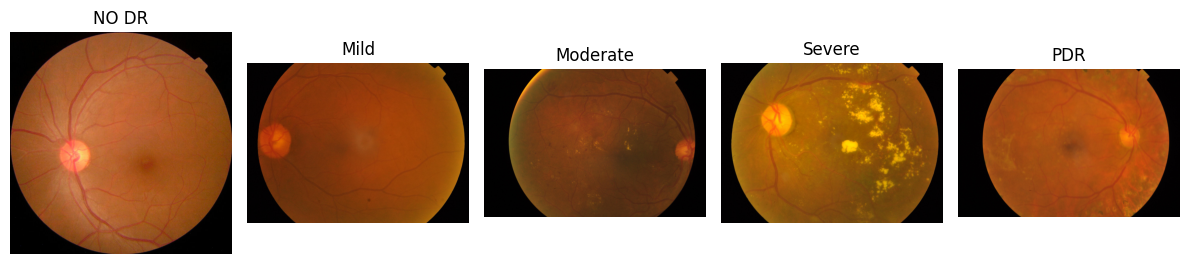

In [10]:
# Correct paths for Kaggle
TRAIN_CSV = '/kaggle/input/aptos2019-blindness-detection/train.csv'
TRAIN_IMG_PATH = '/kaggle/input/aptos2019-blindness-detection/train_images'

# Load data
df = pd.read_csv(TRAIN_CSV)

label_map = {
    0: "NO DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "PDR"
}

plt.figure(figsize=(12, 6))

for idx, (label, class_name) in enumerate(label_map.items()):
    img_id = df[df["diagnosis"] == label].iloc[0]["id_code"]
    img_path = os.path.join(TRAIN_IMG_PATH, img_id + ".png")  # Note the + ".png"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported!")

All libraries imported!


In [11]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df['id_code'] = train_df['id_code'] + '.png'
test_df['id_code'] = test_df['id_code'] + '.png'
train_df['diagnosis'] = train_df['diagnosis'].astype(str)

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 3662
Test samples: 1928


 2. Data Exploration and Visualization


In [12]:
df = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/train.csv')
diagnosis_dict_binary = {
    0: 0,
    1: 1,
    2: 1,
    3: 1,
    4: 1
}

diagnosis_dict = {
    0: 'No_DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate_DR',
}


df['binary_type'] =  df['diagnosis'].map(diagnosis_dict_binary.get)
df['type'] = df['diagnosis'].map(diagnosis_dict.get)
df.head()
df.head()


,id_code,diagnosis,binary_type,type
0,000c1434d8d7,2,1,Moderate
1,001639a390f0,4,1,Proliferate_DR
2,0024cdab0c1e,1,1,Mild
3,002c21358ce6,0,0,No_DR
4,005b95c28852,0,0,No_DR


## 3. Class Distribution Analysis


<Axes: ylabel='type'>

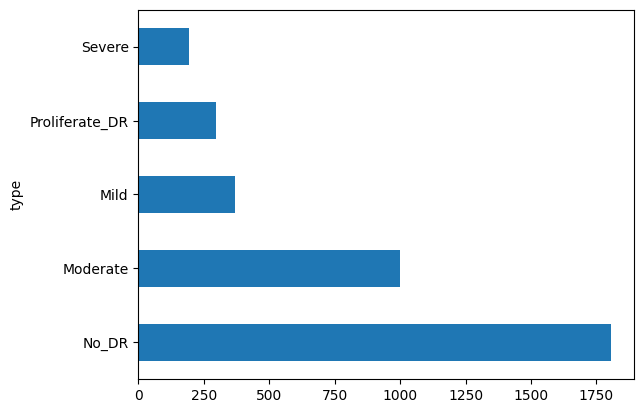

In [8]:
df['type'].value_counts().plot(kind='barh')

<Axes: ylabel='binary_type'>

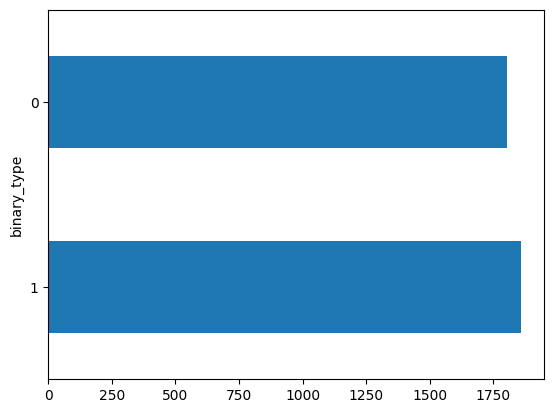

In [9]:
df['binary_type'].value_counts().plot(kind='barh')

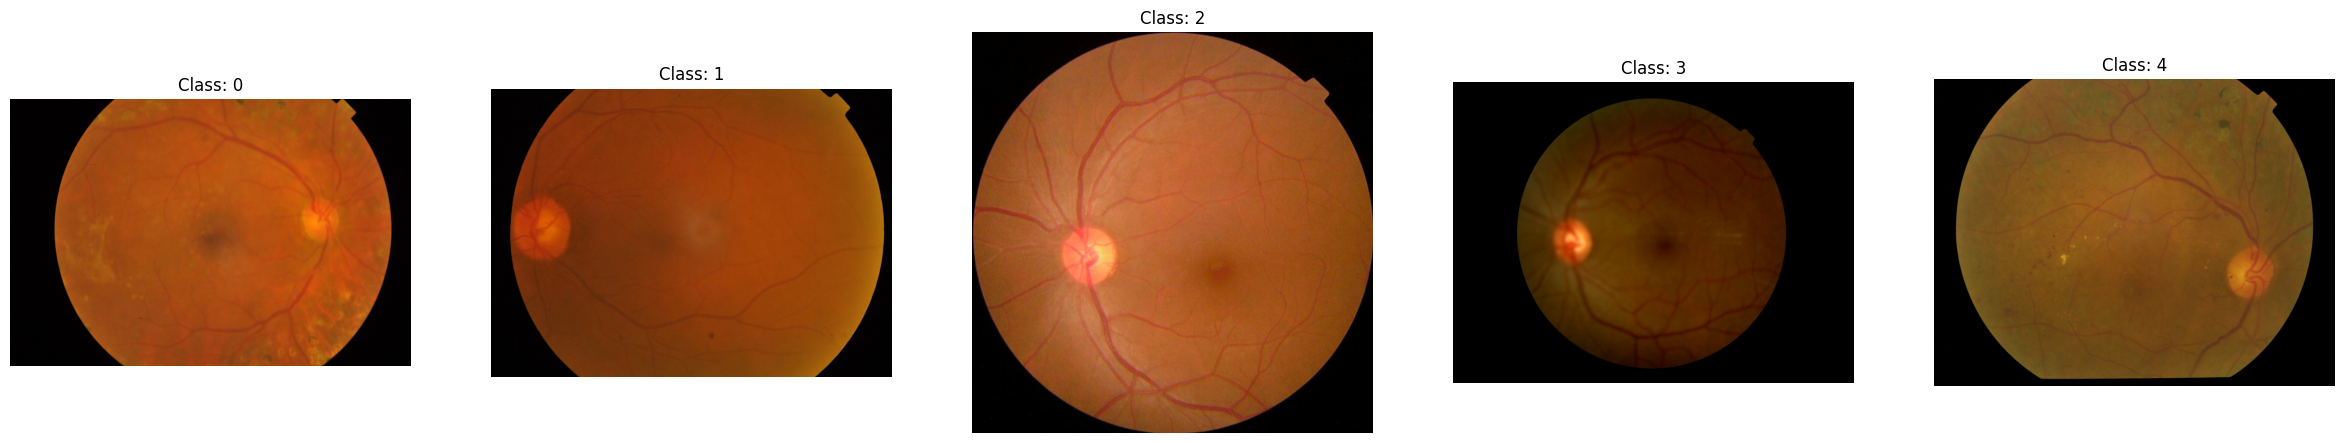

In [7]:
image_ids = [
    "001639a390f0",
    "0024cdab0c1e",
    "002c21358ce6",
    "005b95c28852",
    "0083ee8054ee"
]

plt.figure(figsize=(30, 30))

for i, img_id in enumerate(image_ids):
    img_path = os.path.join(TRAIN_IMG_PATH, img_id + ".png")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Class: {i}")

plt.show()

In [12]:
print("Total samples:", len(df))
print(df['diagnosis'].value_counts())

Total samples: 3662
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


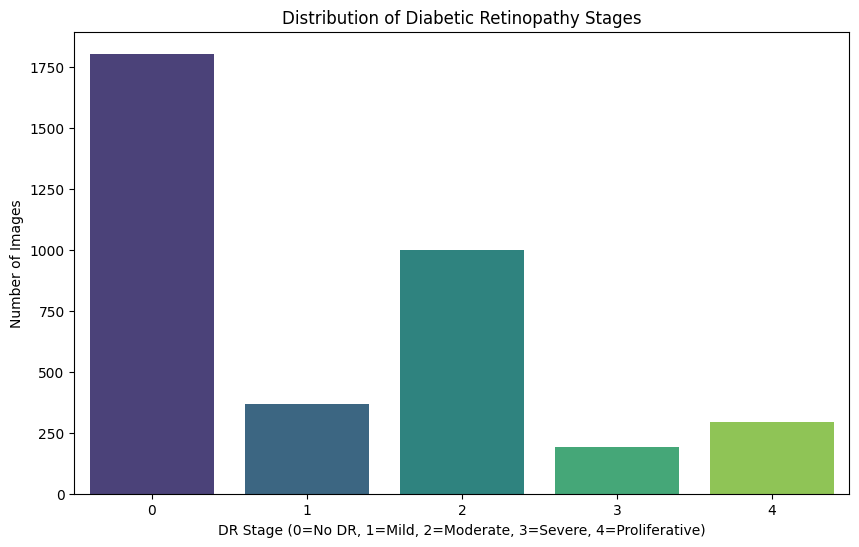

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='diagnosis', data=train_df, order=['0','1','2','3','4'], palette='viridis')
plt.title('Distribution of Diabetic Retinopathy Stages')
plt.xlabel('DR Stage (0=No DR, 1=Mild, 2=Moderate, 3=Severe, 4=Proliferative)')
plt.ylabel('Number of Images')
plt.show()

print("Class distribution:")
print(train_df['diagnosis'].value_counts().sort_index())

## 4. Image Preprocessing
### 4.1 Gaussian Blur Visualization


In [13]:
IMG_DIR = "/kaggle/input/aptos2019-blindness-detection/train_images"


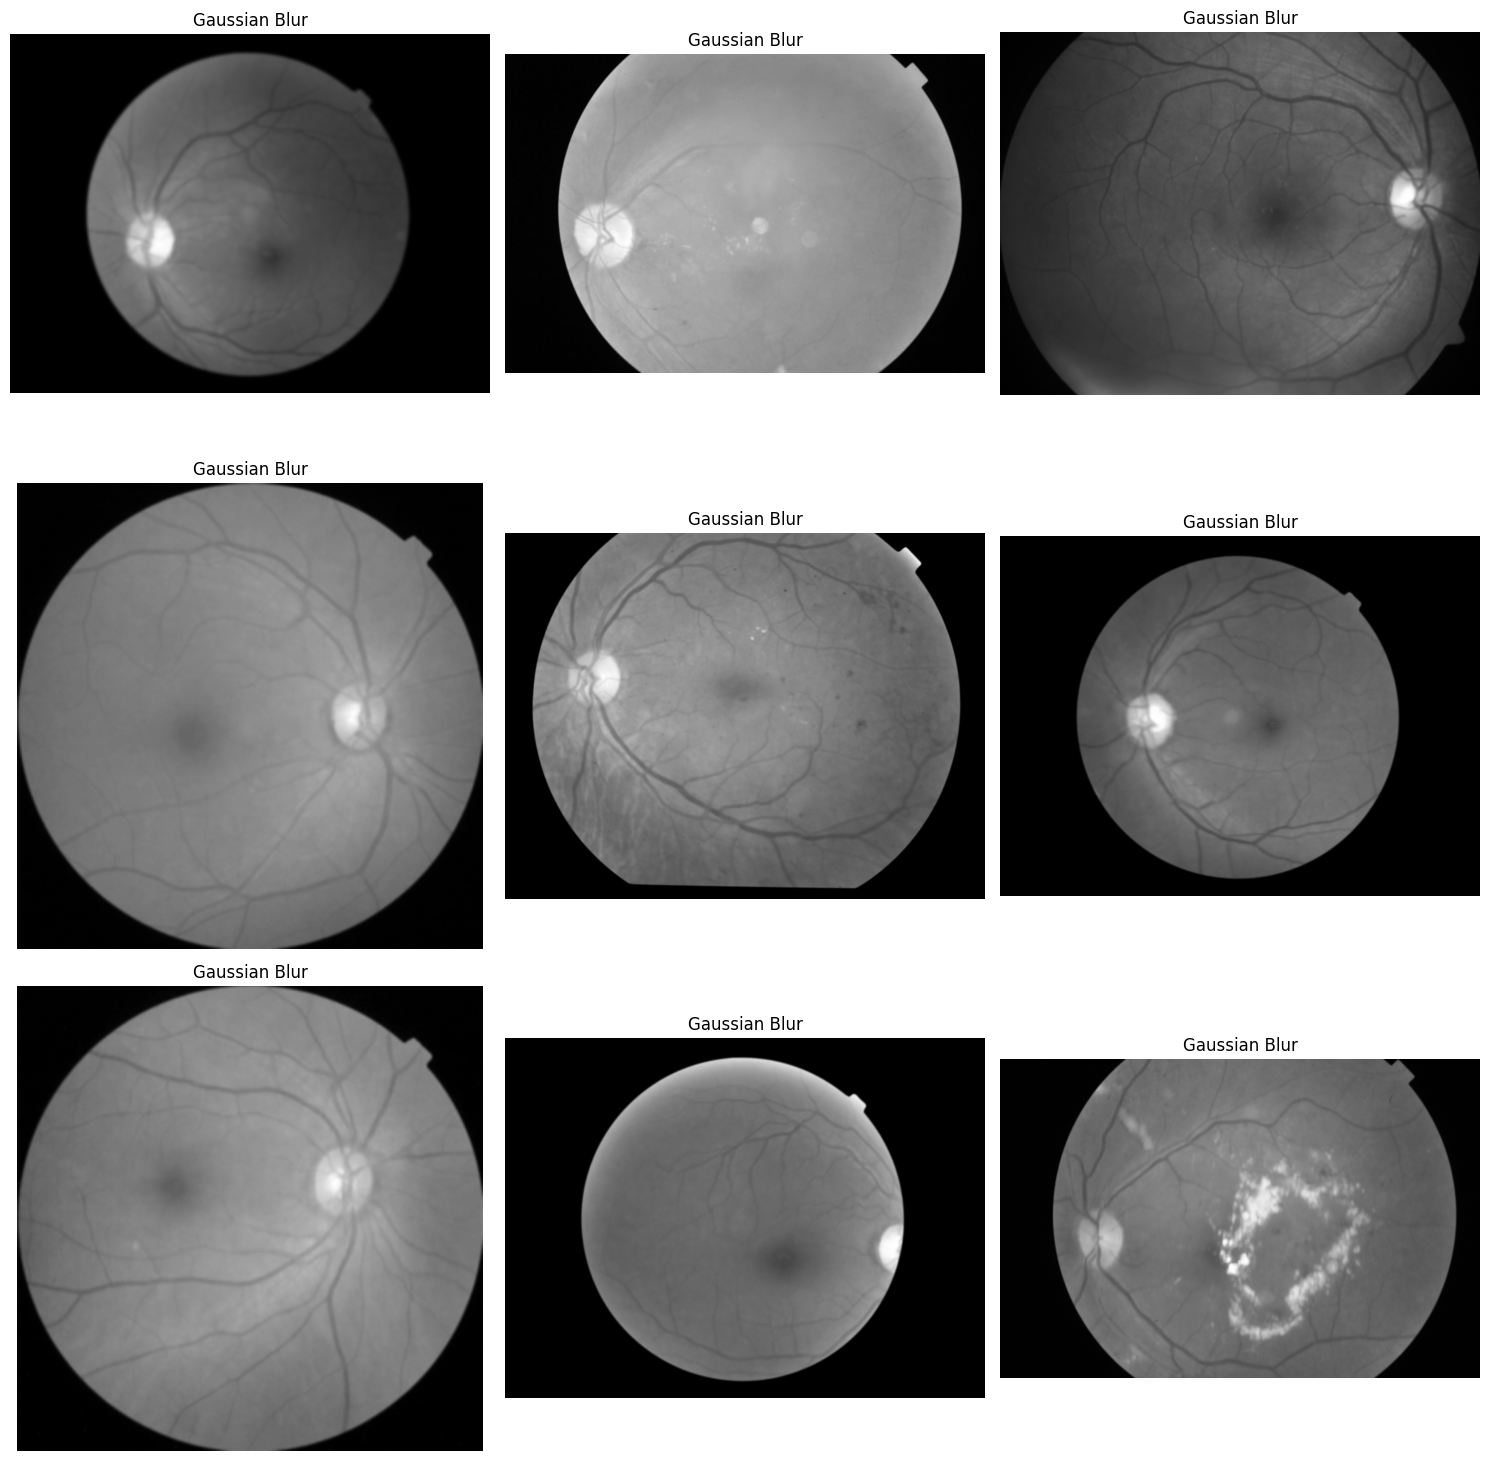

In [11]:
image_files = os.listdir(IMG_DIR)[:9]

plt.figure(figsize=(15, 15))

for i, img_file in enumerate(image_files):
    img_path = os.path.join(IMG_DIR, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(img, (15, 15), 0)  # kernel size 15×15 = strong blur
    
    # Convert to grayscale (gray color)
    gray_blurred = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(gray_blurred, cmap='gray')  # gray colormap
    plt.title(f"Gaussian Blur")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4.2 Image Normalization and Resizing


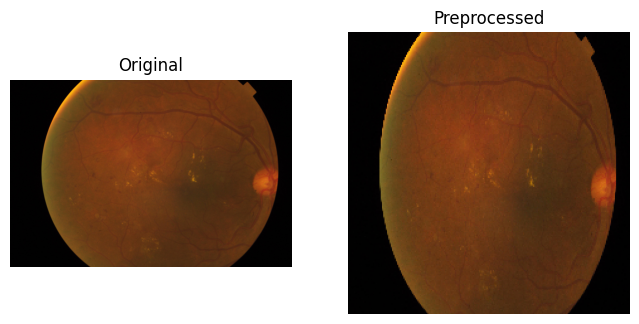

In [16]:

IMG_SIZE = 224

def cpu_preprocess(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    return image / 255.0

sample_path = os.path.join(TRAIN_IMG_PATH, train_df['id_code'].iloc[0])
original = cv2.imread(sample_path)
processed = cpu_preprocess(original)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(processed); plt.title("Preprocessed"); plt.axis('off')
plt.show()

## 5. ResNet50 Model Implementation


In [17]:

BATCH_SIZE = 8

from sklearn.utils.class_weight import compute_class_weight
labels_int = train_df['diagnosis'].astype(int).values
class_weights = compute_class_weight('balanced', classes=np.unique(labels_int), y=labels_int)
class_weight_dict = {i: class_weights[i] for i in range(5)}
print("Class weights:", class_weight_dict)

datagen = ImageDataGenerator(
    validation_split=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    preprocessing_function=cpu_preprocess
)

train_gen = datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_IMG_PATH,
    x_col='id_code',
    y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_IMG_PATH,
    x_col='id_code',
    y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Class weights: {0: np.float64(0.4057617728531856), 1: np.float64(1.9794594594594594), 2: np.float64(0.7331331331331331), 3: np.float64(3.7948186528497407), 4: np.float64(2.4827118644067796)}
Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.


### 5.1 ResNet50 Architecture


In [ ]:

base_model = applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.5)(x)
output = layers.Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 ready for CPU training (Stage 1: Classifier only)")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 ready for CPU training (Stage 1: Classifier only)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:

checkpoint = ModelCheckpoint('best_resnet_cpu.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)


print("=== Stage 1: Training classifier (10 epochs) ===")
history1 = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=val_gen.samples // BATCH_SIZE,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)


print("=== Stage 2: Fine-tuning top layers (5 epochs) ===")
base_model.trainable = True


for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=val_gen.samples // BATCH_SIZE,
    epochs=5,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print("Training completed! Best model saved as 'best_resnet_cpu.h5'")

=== Stage 1: Training classifier (10 epochs) ===
Epoch 1/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2808 - loss: 1.6252
Epoch 1: val_accuracy improved from -inf to 0.08104, saving model to best_resnet_cpu.h5


366/366 ━━━━━━━━━━━━━━━━━━━━ 1146s 3s/step - accuracy: 0.2807 - loss: 1.6253 - val_accuracy: 0.0810 - val_loss: 1.6856 - learning_rate: 5.0000e-04
Epoch 2/10
  1/366 ━━━━━━━━━━━━━━━━━━━━ 7:42 1s/step - accuracy: 0.1250 - loss: 1.4351
Epoch 2: val_accuracy did not improve from 0.08104
366/366 ━━━━━━━━━━━━━━━━━━━━ 232s 633ms/step - accuracy: 0.1250 - loss: 1.4351 - val_accuracy: 0.0810 - val_loss: 1.6737 - learning_rate: 5.0000e-04
Epoch 3/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2348 - loss: 1.6542
Epoch 3: val_accuracy improved from 0.08104 to 0.46703, saving model to best_resnet_cpu.h5


366/366 ━━━━━━━━━━━━━━━━━━━━ 1166s 3s/step - accuracy: 0.2349 - loss: 1.6541 - val_accuracy: 0.4670 - val_loss: 1.4346 - learning_rate: 5.0000e-04
Epoch 4/10
  1/366 ━━━━━━━━━━━━━━━━━━━━ 7:24 1s/step - accuracy: 0.7500 - loss: 0.7912
Epoch 4: val_accuracy improved from 0.46703 to 0.46978, saving model to best_resnet_cpu.h5


366/366 ━━━━━━━━━━━━━━━━━━━━ 225s 613ms/step - accuracy: 0.7500 - loss: 0.7912 - val_accuracy: 0.4698 - val_loss: 1.4380 - learning_rate: 5.0000e-04
Epoch 5/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3102 - loss: 1.5820
Epoch 5: val_accuracy did not improve from 0.46978
366/366 ━━━━━━━━━━━━━━━━━━━━ 1173s 3s/step - accuracy: 0.3101 - loss: 1.5821 - val_accuracy: 0.1429 - val_loss: 1.6903 - learning_rate: 5.0000e-04
Epoch 6/10
  1/366 ━━━━━━━━━━━━━━━━━━━━ 7:24 1s/step - accuracy: 0.0000e+00 - loss: 1.6702
Epoch 6: val_accuracy did not improve from 0.46978

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
366/366 ━━━━━━━━━━━━━━━━━━━━ 224s 611ms/step - accuracy: 0.0000e+00 - loss: 1.6702 - val_accuracy: 0.1484 - val_loss: 1.6883 - learning_rate: 5.0000e-04
Epoch 7/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2813 - loss: 1.5901
Epoch 7: val_accuracy did not improve from 0.46978
366/366 ━━━━━━━━━━━━━━━━━━━━ 1227s 3s/step - accuracy: 0.281

366/366 ━━━━━━━━━━━━━━━━━━━━ 1308s 4s/step - accuracy: 0.5019 - loss: 1.4449 - val_accuracy: 0.5357 - val_loss: 1.0344 - learning_rate: 1.0000e-05
Epoch 4/5
  1/366 ━━━━━━━━━━━━━━━━━━━━ 13:50 2s/step - accuracy: 0.8750 - loss: 0.4351
Epoch 4: val_accuracy improved from 0.53571 to 0.54258, saving model to best_resnet_cpu.h5


366/366 ━━━━━━━━━━━━━━━━━━━━ 277s 753ms/step - accuracy: 0.8750 - loss: 0.4351 - val_accuracy: 0.5426 - val_loss: 1.0378 - learning_rate: 1.0000e-05
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5384 - loss: 1.3677
Epoch 5: val_accuracy improved from 0.54258 to 0.56731, saving model to best_resnet_cpu.h5


366/366 ━━━━━━━━━━━━━━━━━━━━ 1378s 4s/step - accuracy: 0.5384 - loss: 1.3677 - val_accuracy: 0.5673 - val_loss: 1.0232 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 5.
Training completed! Best model saved as 'best_resnet_cpu.h5'


In [ ]:
model.load_weights('best_resnet_cpu.h5')

In [ ]:
val_gen.reset()
val_preds = model.predict(val_gen, steps=val_gen.samples // val_gen.batch_size + 1)
val_true = val_gen.classes
val_pred_classes = np.argmax(val_preds, axis=1)

92/92 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step


### 5.2 Model Evaluation


In [ ]:
kappa = cohen_kappa_score(val_true, val_pred_classes, weights='quadratic')
print(f"\nValidation Quadratic Weighted Kappa: {kappa:.4f}")


Validation Quadratic Weighted Kappa: 0.4598


In [ ]:
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


92/92 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.6206 - loss: 0.9896
Validation Accuracy: 60.25%


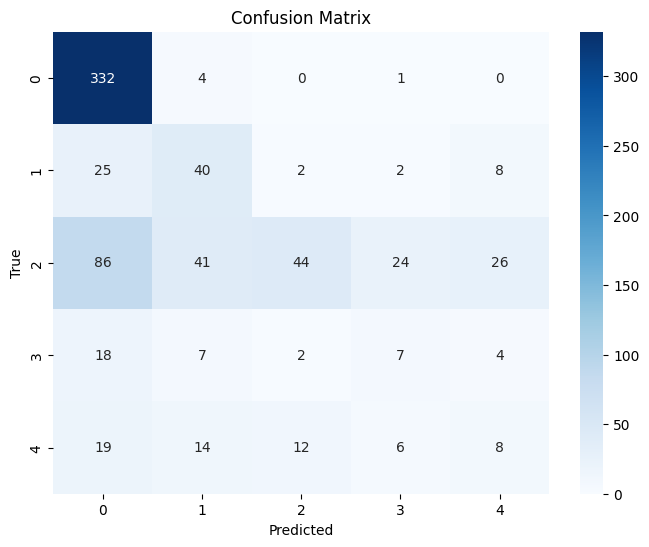

In [ ]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(val_true, val_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

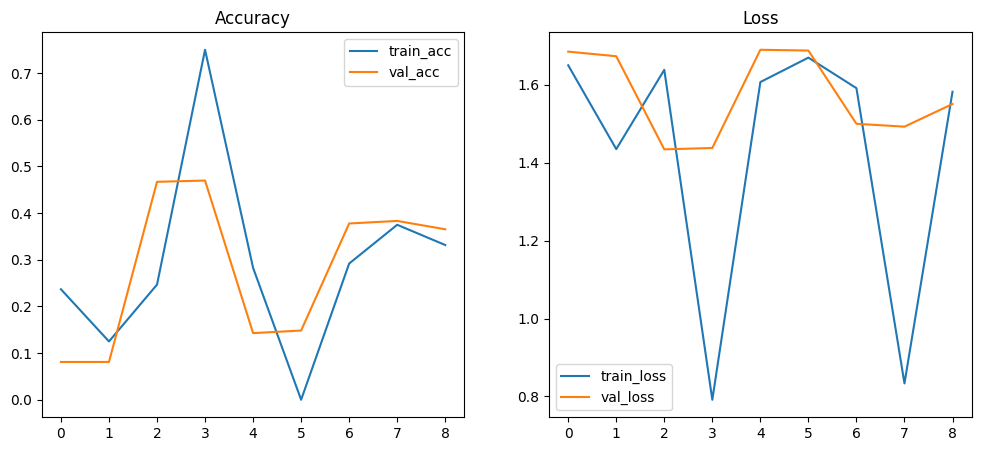

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'], label='train_acc')
plt.plot(history1.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history1.history['loss'], label='train_loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.show()


In [ ]:
model.save('final_resnet50_dr_model.h5')
print("Final model saved!")

Final model saved!


In [ ]:
IMG_SIZE = 224

def eff_preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img


In [ ]:
BATCH_SIZE = 8

labels_int = train_df['diagnosis'].astype(int).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_int),
    y=labels_int
)
class_weight_dict = dict(enumerate(class_weights))

datagen = ImageDataGenerator(
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    preprocessing_function=eff_preprocess
)

train_gen = datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_IMG_PATH,
    x_col="id_code",
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_IMG_PATH,
    x_col="id_code",
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.


## 6. EfficientNetB0 Model Implementation


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(5, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,219,304 (16.10 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_efficientnetb0.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


### 6.1 Training and Fine-Tuning


In [ ]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)


Epoch 1/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4727 - loss: 2.1661
Epoch 1: val_accuracy improved from -inf to 0.63251, saving model to best_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 1611s 4s/step - accuracy: 0.4728 - loss: 2.1652 - val_accuracy: 0.6325 - val_loss: 0.8872 - learning_rate: 0.0010
Epoch 2/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5931 - loss: 1.4763
Epoch 2: val_accuracy did not improve from 0.63251
367/367 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - accuracy: 0.5931 - loss: 1.4761 - val_accuracy: 0.6257 - val_loss: 0.8847 - learning_rate: 0.0010
Epoch 3/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6154 - loss: 1.1616
Epoch 3: val_accuracy improved from 0.63251 to 0.65164, saving model to best_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.6154 - loss: 1.1616 - val_accuracy: 0.6516 - val_loss: 0.8787 - learning_rate: 0.0010
Epoch 4/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6028 - loss: 1.2556
Epoch 4: val_accuracy improved from 0.65164 to 0.68306, saving model to best_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.6028 - loss: 1.2554 - val_accuracy: 0.6831 - val_loss: 0.7902 - learning_rate: 0.0010
Epoch 5/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6529 - loss: 1.1064
Epoch 5: val_accuracy did not improve from 0.68306
367/367 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.6528 - loss: 1.1064 - val_accuracy: 0.6721 - val_loss: 0.7482 - learning_rate: 0.0010
Epoch 6/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6496 - loss: 1.0388
Epoch 6: val_accuracy did not improve from 0.68306
367/367 ━━━━━━━━━━━━━━━━━━━━ 507s 1s/step - accuracy: 0.6495 - loss: 1.0389 - val_accuracy: 0.6530 - val_loss: 0.7848 - learning_rate: 0.0010
Epoch 7/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6633 - loss: 1.0031
Epoch 7: val_accuracy improved from 0.68306 to 0.69809, saving model to best_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 554s 1s/step - accuracy: 0.6632 - loss: 1.0033 - val_accuracy: 0.6981 - val_loss: 0.7146 - learning_rate: 0.0010
Epoch 8/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6570 - loss: 1.0263
Epoch 8: val_accuracy did not improve from 0.69809
367/367 ━━━━━━━━━━━━━━━━━━━━ 494s 1s/step - accuracy: 0.6570 - loss: 1.0263 - val_accuracy: 0.6585 - val_loss: 0.7590 - learning_rate: 0.0010
Epoch 9/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6634 - loss: 0.9945
Epoch 9: val_accuracy did not improve from 0.69809
367/367 ━━━━━━━━━━━━━━━━━━━━ 497s 1s/step - accuracy: 0.6634 - loss: 0.9945 - val_accuracy: 0.6817 - val_loss: 0.7554 - learning_rate: 0.0010
Epoch 10/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6763 - loss: 0.9723
Epoch 10: val_accuracy improved from 0.69809 to 0.70765, saving model to best_efficientnetb0.h5



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
367/367 ━━━━━━━━━━━━━━━━━━━━ 497s 1s/step - accuracy: 0.6763 - loss: 0.9723 - val_accuracy: 0.7077 - val_loss: 0.7397 - learning_rate: 0.0010
Epoch 11/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6763 - loss: 0.9164
Epoch 11: val_accuracy did not improve from 0.70765
367/367 ━━━━━━━━━━━━━━━━━━━━ 483s 1s/step - accuracy: 0.6763 - loss: 0.9165 - val_accuracy: 0.6940 - val_loss: 0.7408 - learning_rate: 5.0000e-04
Epoch 12/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6850 - loss: 0.9195
Epoch 12: val_accuracy did not improve from 0.70765
367/367 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.6850 - loss: 0.9195 - val_accuracy: 0.6872 - val_loss: 0.7206 - learning_rate: 5.0000e-04
Epoch 13/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6897 - loss: 0.9059
Epoch 13: val_accuracy did not improve from 0.70765
367/367 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.6897 - loss: 0.906

367/367 ━━━━━━━━━━━━━━━━━━━━ 503s 1s/step - accuracy: 0.7068 - loss: 0.9091 - val_accuracy: 0.7404 - val_loss: 0.6487 - learning_rate: 5.0000e-04
Epoch 18/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7320 - loss: 0.8584
Epoch 18: val_accuracy did not improve from 0.74044
367/367 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.7320 - loss: 0.8585 - val_accuracy: 0.7158 - val_loss: 0.6653 - learning_rate: 5.0000e-04
Epoch 19/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7173 - loss: 0.9038
Epoch 19: val_accuracy did not improve from 0.74044
367/367 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.7172 - loss: 0.9039 - val_accuracy: 0.7158 - val_loss: 0.7003 - learning_rate: 5.0000e-04
Epoch 20/25
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7046 - loss: 0.9013
Epoch 20: val_accuracy did not improve from 0.74044

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
367/367 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - accuracy: 0.7046 - loss: 0

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


checkpoint2 = ModelCheckpoint(
    "best_finetuned_efficientnetb0.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[checkpoint2, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5220 - loss: 1.3268
Epoch 1: val_accuracy improved from -inf to 0.64891, saving model to best_finetuned_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 535s 1s/step - accuracy: 0.5220 - loss: 1.3268 - val_accuracy: 0.6489 - val_loss: 0.8336 - learning_rate: 1.0000e-05
Epoch 2/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5609 - loss: 1.2477
Epoch 2: val_accuracy improved from 0.64891 to 0.65984, saving model to best_finetuned_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.5609 - loss: 1.2476 - val_accuracy: 0.6598 - val_loss: 0.8209 - learning_rate: 1.0000e-05
Epoch 3/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5688 - loss: 1.1909
Epoch 3: val_accuracy did not improve from 0.65984
367/367 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.5688 - loss: 1.1909 - val_accuracy: 0.6530 - val_loss: 0.8169 - learning_rate: 1.0000e-05
Epoch 4/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5941 - loss: 1.1948
Epoch 4: val_accuracy improved from 0.65984 to 0.66257, saving model to best_finetuned_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 514s 1s/step - accuracy: 0.5941 - loss: 1.1947 - val_accuracy: 0.6626 - val_loss: 0.7897 - learning_rate: 1.0000e-05
Epoch 5/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5976 - loss: 1.1262
Epoch 5: val_accuracy did not improve from 0.66257
367/367 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.5976 - loss: 1.1262 - val_accuracy: 0.6516 - val_loss: 0.7930 - learning_rate: 1.0000e-05
Epoch 6/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6292 - loss: 1.0804
Epoch 6: val_accuracy improved from 0.66257 to 0.66530, saving model to best_finetuned_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/step - accuracy: 0.6292 - loss: 1.0803 - val_accuracy: 0.6653 - val_loss: 0.7781 - learning_rate: 1.0000e-05
Epoch 7/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6240 - loss: 1.0902
Epoch 7: val_accuracy did not improve from 0.66530
367/367 ━━━━━━━━━━━━━━━━━━━━ 580s 1s/step - accuracy: 0.6240 - loss: 1.0902 - val_accuracy: 0.6598 - val_loss: 0.7694 - learning_rate: 1.0000e-05
Epoch 8/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6324 - loss: 1.0709
Epoch 8: val_accuracy improved from 0.66530 to 0.67760, saving model to best_finetuned_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - accuracy: 0.6324 - loss: 1.0709 - val_accuracy: 0.6776 - val_loss: 0.7435 - learning_rate: 1.0000e-05
Epoch 9/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6228 - loss: 1.1061
Epoch 9: val_accuracy did not improve from 0.67760
367/367 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.6228 - loss: 1.1060 - val_accuracy: 0.6489 - val_loss: 0.7699 - learning_rate: 1.0000e-05
Epoch 10/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6374 - loss: 1.0359
Epoch 10: val_accuracy did not improve from 0.67760
367/367 ━━━━━━━━━━━━━━━━━━━━ 522s 1s/step - accuracy: 0.6374 - loss: 1.0359 - val_accuracy: 0.6776 - val_loss: 0.7600 - learning_rate: 1.0000e-05
Epoch 11/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6613 - loss: 1.0084
Epoch 11: val_accuracy improved from 0.67760 to 0.68306, saving model to best_finetuned_efficientnetb0.h5


367/367 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/step - accuracy: 0.6613 - loss: 1.0084 - val_accuracy: 0.6831 - val_loss: 0.7338 - learning_rate: 1.0000e-05
Epoch 12/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6366 - loss: 1.0314
Epoch 12: val_accuracy did not improve from 0.68306
367/367 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.6367 - loss: 1.0314 - val_accuracy: 0.6721 - val_loss: 0.7329 - learning_rate: 1.0000e-05
Epoch 13/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6590 - loss: 1.0530
Epoch 13: val_accuracy did not improve from 0.68306
367/367 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.6590 - loss: 1.0530 - val_accuracy: 0.6817 - val_loss: 0.7308 - learning_rate: 1.0000e-05
Epoch 14/15
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6453 - loss: 1.0137
Epoch 14: val_accuracy did not improve from 0.68306
367/367 ━━━━━━━━━━━━━━━━━━━━ 522s 1s/step - accuracy: 0.6453 - loss: 1.0137 - val_accuracy: 0.6831 - val_loss: 0.7316 - learning_rate: 1.0000e-05
Ep

367/367 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - accuracy: 0.6271 - loss: 1.0043 - val_accuracy: 0.6926 - val_loss: 0.7202 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 15.


In [ ]:
model.load_weights("best_finetuned_efficientnetb0.h5")

In [ ]:
val_gen.reset()
val_probs = model.predict(val_gen)
val_preds = np.argmax(val_probs, axis=1)
val_true = val_gen.classes

92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step


### 6.2 Model Evaluation


In [ ]:
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.7170 - loss: 0.6944
Validation Accuracy: 70.49%


In [ ]:
kappa = cohen_kappa_score(val_true, val_preds, weights="quadratic")
print(f"Raw Quadratic Weighted Kappa: {kappa:.4f}")

Raw Quadratic Weighted Kappa: 0.8373


In [ ]:

best_kappa = kappa
best_thresh = [0.5, 1.5, 2.5, 3.5]

cum_probs = np.cumsum(val_probs, axis=1)
for t1 in np.arange(0.3, 0.9, 0.1):
    for t2 in np.arange(t1+0.4, 1.8, 0.1):
        for t3 in np.arange(t2+0.4, 2.6, 0.1):
            for t4 in np.arange(t3+0.4, 3.5, 0.1):
                preds_opt = np.zeros(len(val_probs))
                preds_opt[cum_probs[:,0] >= t1] = 1
                preds_opt[cum_probs[:,1] >= t2] = 2
                preds_opt[cum_probs[:,2] >= t3] = 3
                preds_opt[cum_probs[:,3] >= t4] = 4
                k = cohen_kappa_score(val_true, preds_opt, weights='quadratic')
                if k > best_kappa:
                    best_kappa = k
                    best_thresh = [t1, t2, t3, t4]
                    val_preds = preds_opt.astype(int)

print(f"Optimized Quadratic Weighted Kappa: {best_kappa:.4f}")
print(f"Best thresholds: {best_thresh}")

Optimized Quadratic Weighted Kappa: 0.8373
Best thresholds: [0.5, 1.5, 2.5, 3.5]


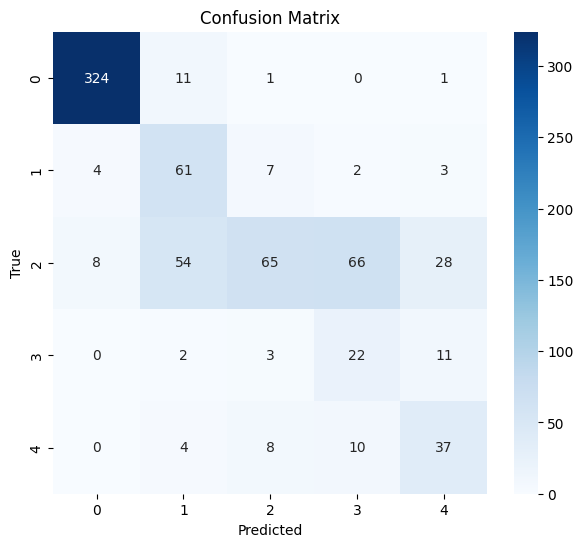

In [ ]:
cm = confusion_matrix(val_true, val_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


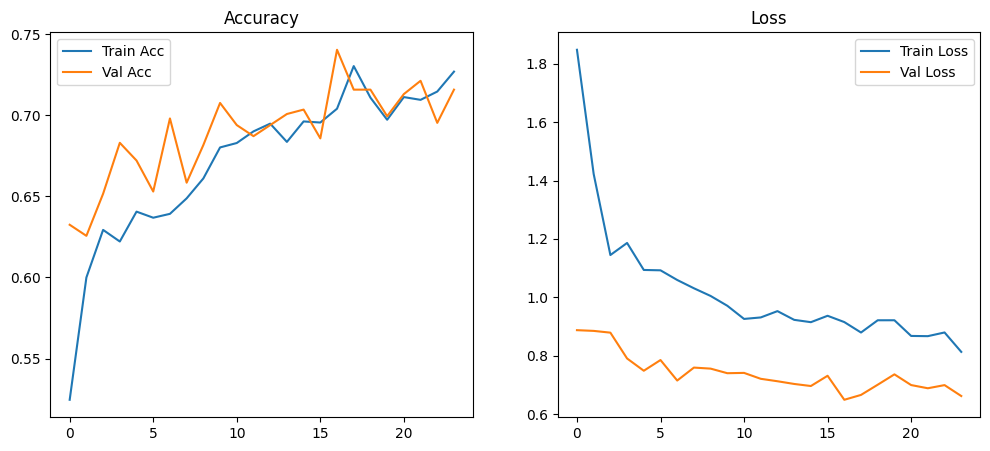

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'], label='Train Acc')
plt.plot(history1.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [ ]:
model.save('final_efficientnetb0_dr_model.keras')
print("EfficientNetB0 model saved successfully!")


EfficientNetB0 model saved successfully!


In [12]:
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_CLASSES = 5
SEED = 2025

In [13]:
def preprocess(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    return preprocess_input(image)


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis']
)
class_weight_dict = dict(enumerate(class_weights))


datagen = ImageDataGenerator(
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=5,
    zoom_range=0.05,
    preprocessing_function=preprocess
)

train_gen = datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_IMG_PATH,
    x_col='id_code',
    y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_IMG_PATH,
    x_col='id_code',
    y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.


7. DenseNet121 Model implementation

In [14]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

I0000 00:00:1769243673.291779      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769243673.295552      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,305,285 (27.87 MB)

 Trainable params: 265,733 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

7.1 Training and Fine tuning 

In [26]:
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_densenet121_stage1.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

tf.keras.backend.clear_session()
train_gen.reset()
val_gen.reset()

In [29]:
history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)


Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6369 - loss: 1.2930
Epoch 1: val_accuracy improved from -inf to 0.69536, saving model to /kaggle/working/best_densenet121_stage1.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 492s 3s/step - accuracy: 0.6369 - loss: 1.2928 - val_accuracy: 0.6954 - val_loss: 0.7609 - learning_rate: 0.0010
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6957 - loss: 0.9761
Epoch 2: val_accuracy improved from 0.69536 to 0.70902, saving model to /kaggle/working/best_densenet121_stage1.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.6956 - loss: 0.9762 - val_accuracy: 0.7090 - val_loss: 0.7300 - learning_rate: 0.0010
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7233 - loss: 0.8418
Epoch 3: val_accuracy improved from 0.70902 to 0.76093, saving model to /kaggle/working/best_densenet121_stage1.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.7233 - loss: 0.8420 - val_accuracy: 0.7609 - val_loss: 0.6500 - learning_rate: 0.0010
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7437 - loss: 0.7833
Epoch 4: val_accuracy did not improve from 0.76093
184/184 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.7437 - loss: 0.7835 - val_accuracy: 0.7609 - val_loss: 0.6137 - learning_rate: 0.0010
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7642 - loss: 0.8130
Epoch 5: val_accuracy did not improve from 0.76093
184/184 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.7642 - loss: 0.8128 - val_accuracy: 0.7404 - val_loss: 0.6647 - learning_rate: 0.0010
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7428 - loss: 0.7798
Epoch 6: val_accuracy did not improve from 0.76093
184/184 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.7429 - loss: 0.7796 - val_accuracy: 0.7254 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 7/15
184/184 ━━━━━

184/184 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.8154 - loss: 0.5659 - val_accuracy: 0.7664 - val_loss: 0.6082 - learning_rate: 3.0000e-04
Epoch 11/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8183 - loss: 0.5378
Epoch 11: val_accuracy did not improve from 0.76639
184/184 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.8183 - loss: 0.5379 - val_accuracy: 0.7596 - val_loss: 0.6370 - learning_rate: 3.0000e-04
Epoch 12/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8448 - loss: 0.4935
Epoch 12: val_accuracy improved from 0.76639 to 0.77322, saving model to /kaggle/working/best_densenet121_stage1.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.8447 - loss: 0.4937 - val_accuracy: 0.7732 - val_loss: 0.6306 - learning_rate: 3.0000e-04
Epoch 13/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8339 - loss: 0.5146
Epoch 13: val_accuracy improved from 0.77322 to 0.78279, saving model to /kaggle/working/best_densenet121_stage1.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.8339 - loss: 0.5146 - val_accuracy: 0.7828 - val_loss: 0.5911 - learning_rate: 3.0000e-04
Epoch 14/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8423 - loss: 0.4968
Epoch 14: val_accuracy improved from 0.78279 to 0.78825, saving model to /kaggle/working/best_densenet121_stage1.h5


184/184 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.8423 - loss: 0.4969 - val_accuracy: 0.7883 - val_loss: 0.6075 - learning_rate: 3.0000e-04
Epoch 15/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8192 - loss: 0.5064
Epoch 15: val_accuracy did not improve from 0.78825
184/184 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.8192 - loss: 0.5064 - val_accuracy: 0.7705 - val_loss: 0.6127 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 13.


In [38]:
model.load_weights("/kaggle/working/best_densenet121_stage1.h5")


In [39]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(2e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint.filepath = "/kaggle/working/best_densenet121_stage2.h5"

train_gen.reset()
val_gen.reset()

In [41]:
history_stage2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)


Epoch 1/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8099 - loss: 0.5703
Epoch 1: val_accuracy did not improve from 0.78825
184/184 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - accuracy: 0.8099 - loss: 0.5702 - val_accuracy: 0.7705 - val_loss: 0.6110 - learning_rate: 2.0000e-05
Epoch 2/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8277 - loss: 0.5351
Epoch 2: val_accuracy did not improve from 0.78825
184/184 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.8277 - loss: 0.5351 - val_accuracy: 0.7678 - val_loss: 0.6364 - learning_rate: 2.0000e-05
Epoch 3/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8312 - loss: 0.5057
Epoch 3: val_accuracy did not improve from 0.78825
184/184 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.8312 - loss: 0.5057 - val_accuracy: 0.7705 - val_loss: 0.6204 - learning_rate: 2.0000e-05
Epoch 4/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8271 - loss: 0.5479
Epoch 4: val_accuracy did not improve from 0.78825
184/184 ━━━━━━━━━━

184/184 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.8658 - loss: 0.4083 - val_accuracy: 0.7951 - val_loss: 0.6143 - learning_rate: 1.8000e-06
Epoch 16/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8578 - loss: 0.4531
Epoch 16: val_accuracy did not improve from 0.79508
184/184 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.8578 - loss: 0.4530 - val_accuracy: 0.7719 - val_loss: 0.6348 - learning_rate: 1.8000e-06
Epoch 17/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8644 - loss: 0.4198
Epoch 17: val_accuracy did not improve from 0.79508

Epoch 17: ReduceLROnPlateau reducing learning rate to 5.399999849942105e-07.
184/184 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.8644 - loss: 0.4198 - val_accuracy: 0.7719 - val_loss: 0.6270 - learning_rate: 1.8000e-06
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 9.


In [42]:
model.load_weights("/kaggle/working/best_densenet121_stage2.h5")

7.2 Model Evaluation

In [55]:
val_loss, val_accuracy = model.evaluate(val_gen, verbose=1)

print(f"Final Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}")


46/46 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.7845 - loss: 0.6099
Final Validation Accuracy: 78.42%
Final Validation Loss: 0.6079


In [57]:

val_gen.reset()

y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_gen.classes

qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
print(f"Validation Quadratic Weighted Kappa: {qwk:.4f}")


46/46 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step
Validation Quadratic Weighted Kappa: 0.8571


46/46 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step


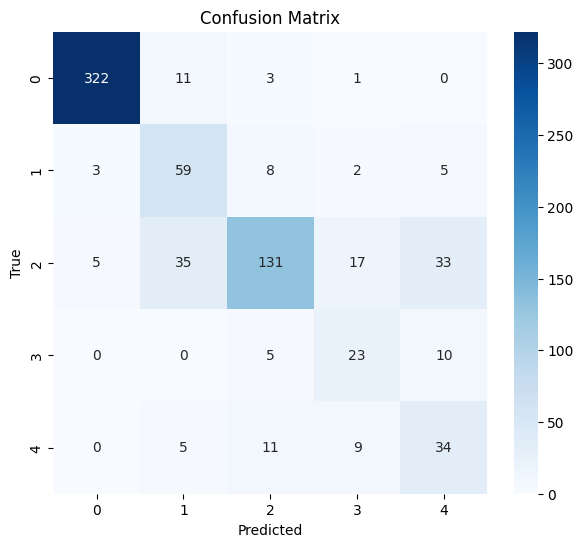

In [58]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


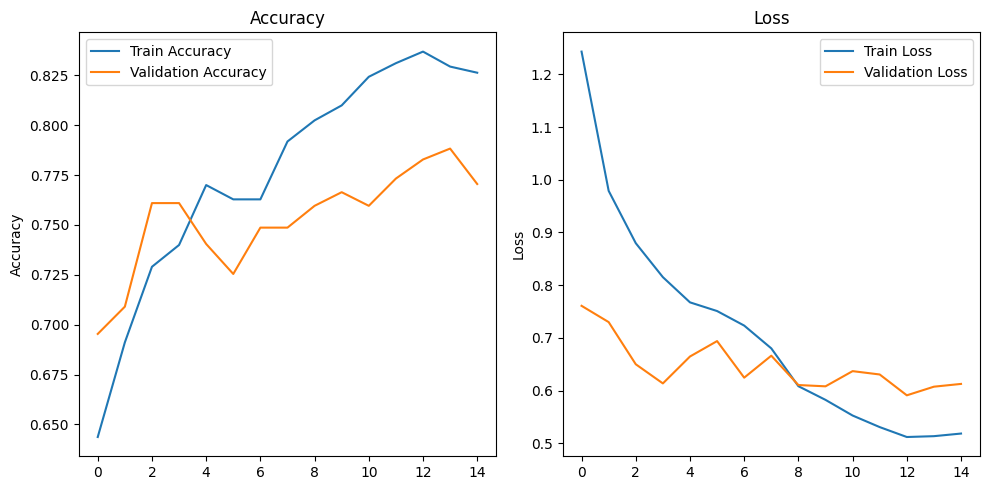

In [70]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(history_stage2.history['accuracy'], ...)   
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [68]:
model.save("final_densenet121_dr_model.keras")
print("DenseNet121 model saved successfully!")



DenseNet121 model saved successfully!


In [18]:
IMG_SIZE = 380          
BATCH_SIZE = 8         
NUM_CLASSES = 5
SEED = 42


In [19]:
CSV_PATH = "/kaggle/input/aptos2019-blindness-detection/train.csv"
IMG_DIR  = "/kaggle/input/aptos2019-blindness-detection/train_images"

df = pd.read_csv(CSV_PATH)


In [22]:
df["id_code"] = df["id_code"].astype(str)

df["id_code"] = df["id_code"].apply(
    lambda x: x if x.endswith(".png") else x + ".png"
)



In [23]:
df['diagnosis'] = df['diagnosis'].astype(str)


datagen = ImageDataGenerator(
    validation_split=0.2,                  
    preprocessing_function=eff_preprocess_input,  
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],            
    fill_mode='nearest'
)


train_gen = datagen.flow_from_dataframe(
    dataframe=df,                           
    directory=TRAIN_IMG_PATH,               
    x_col="id_code",
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED                              
)


val_gen = datagen.flow_from_dataframe(
    dataframe=df,
    directory=TRAIN_IMG_PATH,
    x_col="id_code",
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,                          
    seed=SEED
)

print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")

Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.
Training samples: 2930
Validation samples: 732


8 EfficientNetB4 model implementation

In [28]:
base_model = EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 380, 380,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 18,601,572 (70.96 MB)

 Trainable params: 924,165 (3.53 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [30]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


8.1 Training the model

In [32]:
checkpoint = ModelCheckpoint(
    "/kaggle/working/best_efficientnetb4_stage1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    verbose=1
)


In [ ]:
history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20


I0000 00:00:1769101151.142779     133 service.cc:152] XLA service 0x7cf6440023a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769101151.142827     133 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769101155.449347     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769101176.722017     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6430 - loss: 1.7818
Epoch 1: val_accuracy improved from -inf to 0.74488, saving model to /kaggle/working/best_efficientnetb4_stage1.keras
367/367 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.6431 - loss: 1.7816 - val_accuracy: 0.7449 - val_loss: 0.9224 - learning_rate: 0.0010
Epoch 2/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.7041 - loss: 1.3598
Epoch 2: val_accuracy improved from 0.74488 to 0.75853, saving model to /kaggle/working/best_efficientnetb4_stage1.keras
367/367 ━━━━━━━━━━━━━━━━━━━━ 423s 1s/step - accuracy: 0.7041 - loss: 1.3596 - val_accuracy: 0.7585 - val_loss: 0.9805 - learning_rate: 0.0010
Epoch 3/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.7099 - loss: 0.9920
Epoch 3: val_accuracy did not improve from 0.75853
367/367 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step - accuracy: 0.7100 - loss: 0.9918 - val_accuracy: 0.7353 - val_loss: 1.0209 - learning_rate: 0.0010
Epoch 4/20
367/367 ━━━━━━━━━━━━━━━

In [33]:
from tensorflow.keras.models import load_model
model = load_model(
    "/kaggle/input/aptooos/best_efficientnetb4_stage1.keras"
)

print("Model loaded successfully")


Model loaded successfully


8.2 Model Evaluation

In [34]:
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


I0000 00:00:1769243838.226182     138 service.cc:152] XLA service 0x7e1b2cd7dfb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769243838.226222     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769243838.226226     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769243839.883554     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-24 08:37:26.652453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 08:37:26.790214: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 08:37:27.022742: E external/local_xl

91/92 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7956 - loss: 0.6824

2026-01-24 08:39:21.319048: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 08:39:21.454662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 08:39:21.683876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 08:39:21.820114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 08:39:22.060970: E external/local_xla/xla/stream_

92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7960 - loss: 0.6810
Validation Accuracy: 81.17%


In [35]:

val_gen.reset()

y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_gen.classes

qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
print(f"Validation Quadratic Weighted Kappa: {qwk:.4f}")


92/92 ━━━━━━━━━━━━━━━━━━━━ 98s 937ms/step
Validation Quadratic Weighted Kappa: 0.8552


92/92 ━━━━━━━━━━━━━━━━━━━━ 73s 792ms/step


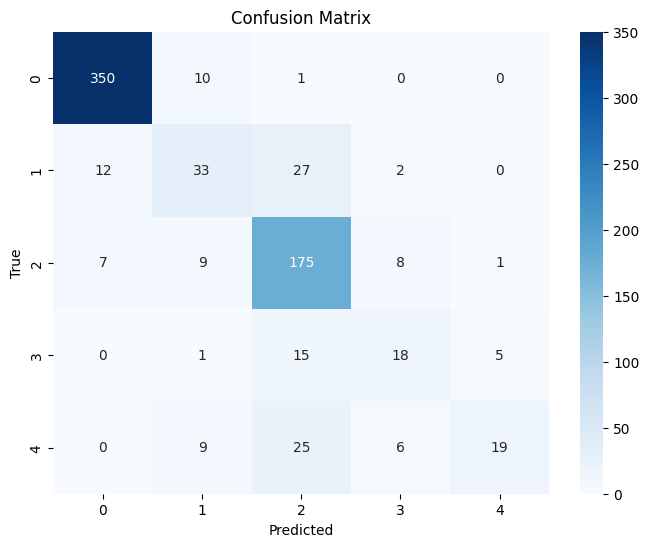

In [36]:

val_pred_probs = model.predict(val_gen, verbose=1)
val_pred_classes = np.argmax(val_pred_probs, axis=1)


val_true = val_gen.classes


cm = confusion_matrix(val_true, val_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


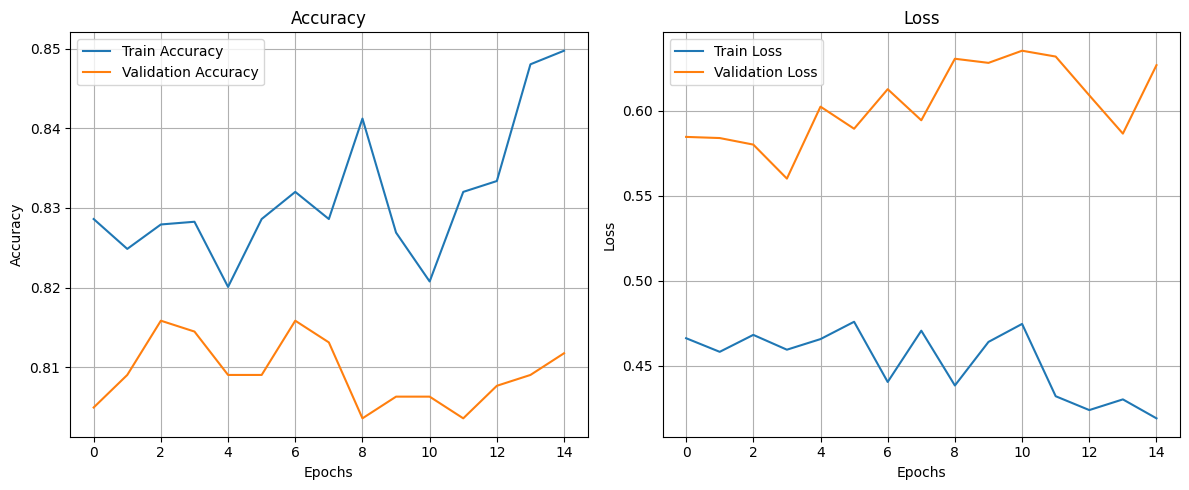

In [44]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history_stage1.history['accuracy'], label='Train Accuracy')
plt.plot(history_stage1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_stage1.history['loss'], label='Train Loss')
plt.plot(history_stage1.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


9 Model Performance Comparison

In [3]:
model_comparison = {
    "Model": [
        "ResNet50",
        "EfficientNetB0",
        "DenseNet121",
        "EfficientNetB4"
    ],
    "Validation Accuracy (%)": [
        60.25,
        70.49,
        78.42,
        81.17
    ]
}

comparison_df = pd.DataFrame(model_comparison)

comparison_df


,Model,Validation Accuracy (%)
0,ResNet50,60.25
1,EfficientNetB0,70.49
2,DenseNet121,78.42
3,EfficientNetB4,81.17


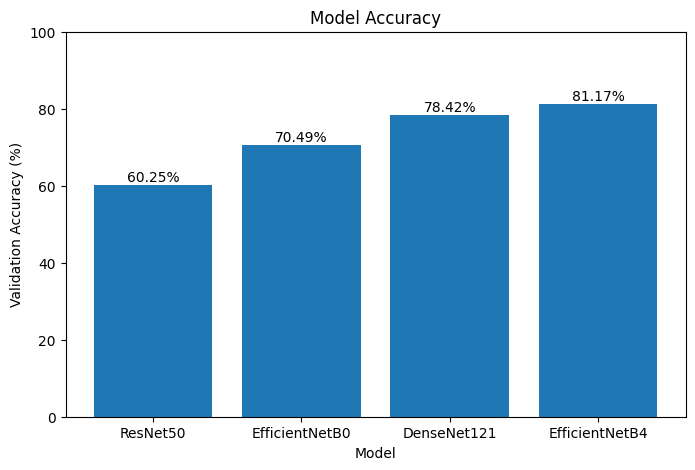

In [5]:
models = ["ResNet50", "EfficientNetB0", "DenseNet121", "EfficientNetB4"]
accuracies = [60.25, 70.49, 78.42, 81.17]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.title("Model Accuracy")

plt.ylim(0, 100)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc}%", ha="center")

plt.show()


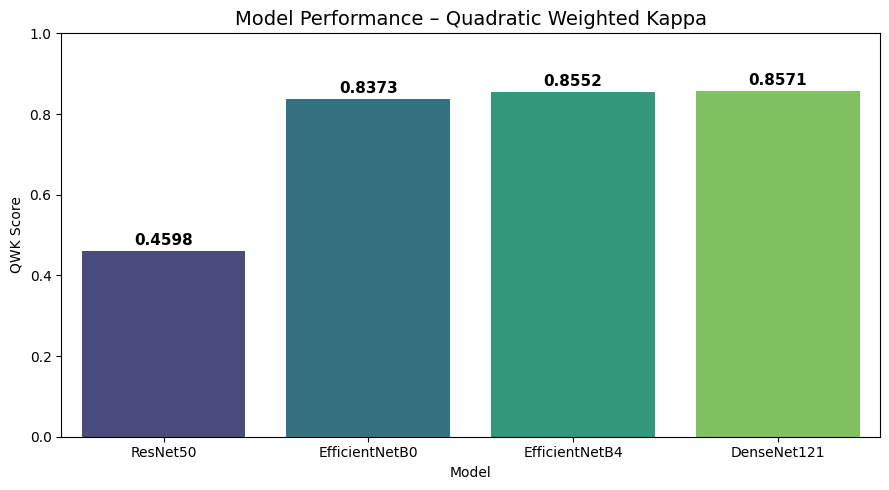

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    "Model": ["ResNet50", "EfficientNetB0", "DenseNet121", "EfficientNetB4"],
    "QWK": [0.4598, 0.8373, 0.8571, 0.8552]
}

df_comp = pd.DataFrame(data).sort_values("QWK", ascending=True)

plt.figure(figsize=(9, 5))
sns.barplot(x="Model", y="QWK", data=df_comp, palette="viridis")
plt.title("Model Performance – Quadratic Weighted Kappa", fontsize=14)
plt.ylim(0, 1.0)
plt.ylabel("QWK Score")
plt.xlabel("Model")

for i, v in enumerate(df_comp["QWK"]):
    plt.text(i, v + 0.015, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()